In [1]:
#importing libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#uploading datasets

from google.colab import files
uploaded = files.upload()

Saving hospital_readmission_dataset.csv to hospital_readmission_dataset.csv


In [4]:
#Loading dataset

df = pd.read_csv("hospital_readmission_dataset.csv")

df.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


In [5]:
# inspecting dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null   objec

In [6]:
# Removing unwanted data features

df = df.drop(columns=[
    "patient_id",
    "admission_date",
    "readmission_risk_score"
])

df.head()

,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,label
0,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,1
1,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,1
2,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,1
3,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,1
4,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,1


In [7]:
# Encoding categorical data

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "season",
    "gender",
    "region",
    "primary_diagnosis",
    "treatment_type",
    "insurance_type",
    "discharge_disposition"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,label
0,1,66,1,3,2,5,6,1,8,6,1,1,1,1
1,0,55,1,3,2,4,6,1,6,4,3,2,1,1
2,1,69,0,4,5,6,8,2,9,6,2,1,3,1
3,2,83,1,3,10,6,11,2,11,4,2,1,3,1
4,0,54,0,2,10,4,10,2,6,2,1,3,1,1


In [8]:
# verifying cleaned data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   season                     8000 non-null   int64
 1   age                        8000 non-null   int64
 2   gender                     8000 non-null   int64
 3   region                     8000 non-null   int64
 4   primary_diagnosis          8000 non-null   int64
 5   comorbidities_count        8000 non-null   int64
 6   length_of_stay             8000 non-null   int64
 7   treatment_type             8000 non-null   int64
 8   medications_count          8000 non-null   int64
 9   followup_visits_last_year  8000 non-null   int64
 10  prev_readmissions          8000 non-null   int64
 11  insurance_type             8000 non-null   int64
 12  discharge_disposition      8000 non-null   int64
 13  label                      8000 non-null   int64
dtypes: int64(14)
memory usag

In [9]:
#Defining features and target

X = df.drop("label", axis=1)

y = df["label"]

In [10]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
# Training multiple models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print("Model:", name)
    print("Accuracy:", accuracy)
    print(classification_report(y_test, predictions))
    print("--------------------------------")

Model: Logistic Regression
Accuracy: 0.813125
              precision    recall  f1-score   support

           0       0.64      0.33      0.44       351
           1       0.83      0.95      0.89      1249

    accuracy                           0.81      1600
   macro avg       0.74      0.64      0.66      1600
weighted avg       0.79      0.81      0.79      1600

--------------------------------
Model: Decision Tree
Accuracy: 0.724375
              precision    recall  f1-score   support

           0       0.39      0.47      0.43       351
           1       0.84      0.80      0.82      1249

    accuracy                           0.72      1600
   macro avg       0.62      0.63      0.62      1600
weighted avg       0.74      0.72      0.73      1600

--------------------------------
Model: Random Forest
Accuracy: 0.791875
              precision    recall  f1-score   support

           0       0.53      0.39      0.45       351
           1       0.84      0.90      0.87  

In [12]:
# Comparing model performances

results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model","Accuracy"]
)

results_df

,Model,Accuracy
0,Logistic Regression,0.813125
1,Decision Tree,0.724375
2,Random Forest,0.791875


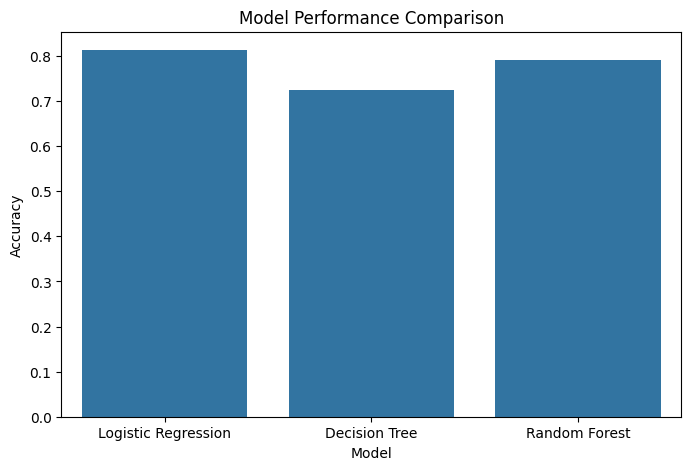

In [13]:
# Visualization

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.title("Model Performance Comparison")
plt.show()

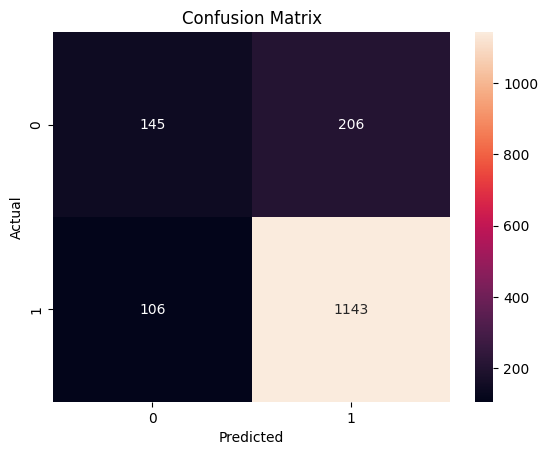

In [14]:
# Confusion matrix(shows prediction correctness)

best_model = RandomForestClassifier()

best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
# saving model for streamlit app

import pickle

pickle.dump(best_model, open("readmission_model.pkl","wb"))

In [16]:
#Test using the test dataset(0-no readmission,1-readmission risk)

predictions = best_model.predict(X_test)

print("Sample Predictions:")
print(predictions[:10])

Sample Predictions:
[1 1 0 1 1 1 1 0 1 1]


In [17]:
# calculating model accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.805


In [18]:
# Classification report(gives better evaluation than accuracy alone)

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.58      0.41      0.48       351
           1       0.85      0.92      0.88      1249

    accuracy                           0.81      1600
   macro avg       0.71      0.66      0.68      1600
weighted avg       0.79      0.81      0.79      1600



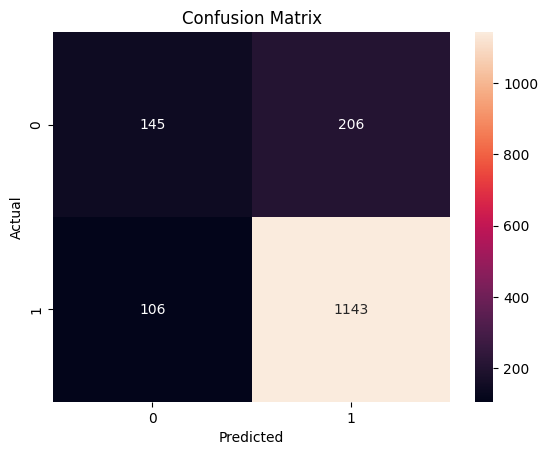

In [19]:
#Confusion matrix showing truenegatives,False postives,false negatives,true negatives
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [20]:
# Testing with new patient data

new_patient = [[
2,   # season
65,  # age
1,   # gender
3,   # region
4,   # primary_diagnosis
2,   # comorbidities_count
6,   # length_of_stay
1,   # treatment_type
5,   # medications_count
3,   # followup_visits_last_year
1,   # prev_readmissions
2,   # insurance_type
1    # discharge_disposition
]]

prediction = best_model.predict(new_patient)

print("Prediction:", prediction)

Prediction: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [21]:
# 0 means no readmission risk

In [22]:
from google.colab import files
files.download("readmission_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>